In [2]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:95% !important;}
div.cell.code_cell.rendered{width:95%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:22pt;}
.inner_cell{font-size:22pt;}
div.text_cell_render pre code {font-size:22pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:22pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:20pt;padding:5px;}
table.dataframe{font-size:22px;}
</style>
"""))

# 데이터셋을 라이브러리에서 가져올 예정. 파일에서도 봄

In [1]:
import numpy as np
import pandas as pd
from tensorflow.keras.datasets import mnist # mnist손글씨 데이터셋
from tensorflow.keras.utils import to_categorical # 원핫인코딩 (pd.getdummies)
from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import Dense, Input, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import ReLU, ELU, LeakyReLU
from matplotlib import pyplot as plt
# train_test_split등을 추가

In [2]:
data = np.loadtxt('data/mnist_train_small.csv', delimiter=',', skiprows=1)
data.shape

(100, 785)

In [16]:
print('타겟변수 :', data[0,0])
image = data[0, 1:].reshape(28,28)
image.shape

타겟변수 : 5.0


(28, 28)

In [17]:
for row in image:
    for pixel in row:
        print(f"{pixel:3.0f}", end='')
    print()# 개행

  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  3 18 18 18126136175 26166255247127  0  0  0  0
  0  0  0  0  0  0  0  0 30 36 94154170253253253253253225172253242195 64  0  0  0  0
  0  0  0  0  0  0  0 49238253253253253253253253253251 93 82 82 56 39  0  0  0  0  0
  0  0  0  0  0  0  0 18219253253253253253198182247241  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0 80156107253253205 11  0 43154  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0 14  1154253 90  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0139253190  2  0  0  0  0  0  0  

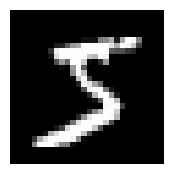

In [10]:
plt.rcParams['figure.figsize']=(2,2)
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.show()

In [ ]:
# 컬러사진을 흑백모드로 넘파이배열로 읽기(pip install opencv-python==4.8.1.78)

In [6]:
%pip install opencv-python==4.8.1.78 
#아나콘다프롬프트들어가서 해도 똑같

Note: you may need to restart the kernel to use updated packages.


In [8]:
import cv2
# 사진이미지를 흑백포멧으로 넘파이배열로 읽어오기
image_array = cv2.imread('data/sample.jpg', cv2.IMREAD_GRAYSCALE)
image_array.shape, type(image_array)

((408, 612), numpy.ndarray)

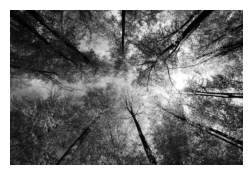

In [11]:
plt.figure(figsize=(3,4))
plt.imshow(image_array, cmap='gray')
plt.axis('off')
plt.show()

# 1. 데이터 생성 및 전처리

In [19]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [21]:
value, counts = np.unique(y_test, return_counts=True)
ratios = counts/y_test.shape[0]
dict(zip(value, ratios))

{0: 0.098,
 1: 0.1135,
 2: 0.1032,
 3: 0.101,
 4: 0.0982,
 5: 0.0892,
 6: 0.0958,
 7: 0.1028,
 8: 0.0974,
 9: 0.1009}

1


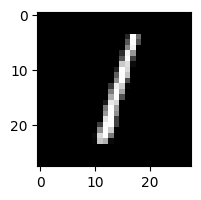

  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 38254109  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 87252 82  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0135241  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 45244150  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 84254 63  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0202223 11  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0 32254216  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0 95254195  0  0  0  0  

In [26]:
print(y_test[2])
plt.imshow(X_test[2], cmap='gray')
plt.show()
for row in X_test[2]:
    for pixel in row:
        print(f"{pixel:3.0f}", end="")
    print()

In [28]:
# Train데이터 6만개 => Train(5만개) + val(만개)로 분리
(X_train, y_train), (X_test, y_test) = mnist.load_data() # 6만개, 만개로 분리되어 load
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]

In [29]:
print('학습셋 :', X_train.shape, y_train.shape)
print('검증셋 :', X_val.shape, y_val.shape)
print('시험셋 :', X_test.shape, y_test.shape)

학습셋 : (50000, 28, 28) (50000,)
검증셋 : (10000, 28, 28) (10000,)
시험셋 : (10000, 28, 28) (10000,)


In [32]:
# 입력(독립)변수 (n,28,28) -> (n,28*28) -> 실수로 형변환 -> 스케일조정(/225.0)
train_X = X_train.reshape(50000, 28*28).astype('float32')/255.0
val_X   = X_val.reshape(10000, 784).astype('float32')/255.0
test_X  = X_test.reshape(10000, -1).astype('float32')/255.0
train_X.shape, val_X.shape, test_X.shape

((50000, 784), (10000, 784), (10000, 784))

In [31]:
train_X[0, 300:350]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.54509807,
       0.99215686, 0.74509805, 0.00784314, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.04313726, 0.74509805, 0.99215686],
      dtype=float32)

In [37]:
# 종속(타겟)변수 : 분류분석을 위한 원핫인코딩(to_categorical()이용, pd.getdummies)
train_Y = to_categorical(y_train, 10)
val_Y   = to_categorical(y_val)
test_Y  = to_categorical(y_test)
train_Y.shape, val_Y.shape, test_Y.shape

((50000, 10), (10000, 10), (10000, 10))

In [39]:
# Train 5만 -> 임의로 700개, val 1만 -> 임의로 300개 추출해서 학습(목적 : 수업시간 중 fit시간절약)
# idx = random.samplt(range(50000), 700)
train_idx = np.random.choice(50000, 700) # 0~50000미만의 700개 수 비복원추출
val_idx   = np.random.choice(10000, 300)
train_X   = train_X[train_idx]
train_Y   = train_Y[train_idx]

In [41]:
train_X.shape, train_Y.shape, val_X.shape, val_Y.shape, test_X.shape, test_Y.shape

((700, 784), (700, 10), (10000, 784), (10000, 10), (10000, 784), (10000, 10))

# 2. 모델 구성
# 3. 학습과정 설정

In [42]:
model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(units=2))
model.add(LeakyReLU(alpha=0.01)) # 음수 결과에 대해 1%만 결과
model.add(Dense(units=10, activation='softmax'))
model.summary()

# 학습과정 설정 : 타겟변수를 원핫인코딩 안 했다면 sparse_categorical_crossentropy
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy']) # 평가지표

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_2 (Dense)             (None, 2)                 1570      
                                                                 
 leaky_re_lu_1 (LeakyReLU)   (None, 2)                 0         
                                                                 
 dense_3 (Dense)             (None, 10)                30        
                                                                 
Total params: 1,600
Trainable params: 1,600
Non-trainable params: 0
_________________________________________________________________


# 4. 모델 학습

In [43]:
%%time
hist = model.fit(train_X, train_Y, #학습셋
                validation_data=(val_X, val_Y), # 검증셋
                batch_size=100,
                epochs=200)

Epoch 1/200
7/7 [==============================] - 1s 79ms/step - loss: 2.3377 - accuracy: 0.0971 - val_loss: 2.3121 - val_accuracy: 0.1027
Epoch 2/200
7/7 [==============================] - 0s 35ms/step - loss: 2.3072 - accuracy: 0.1300 - val_loss: 2.3034 - val_accuracy: 0.1111
Epoch 3/200
7/7 [==============================] - 0s 35ms/step - loss: 2.3009 - accuracy: 0.1414 - val_loss: 2.3020 - val_accuracy: 0.1130
Epoch 4/200
7/7 [==============================] - 0s 29ms/step - loss: 2.2980 - accuracy: 0.1457 - val_loss: 2.3004 - val_accuracy: 0.1188
Epoch 5/200
7/7 [==============================] - 0s 33ms/step - loss: 2.2935 - accuracy: 0.1643 - val_loss: 2.2944 - val_accuracy: 0.1367
Epoch 6/200
7/7 [==============================] - 0s 31ms/step - loss: 2.2768 - accuracy: 0.1843 - val_loss: 2.2719 - val_accuracy: 0.1784
Epoch 7/200
7/7 [==============================] - 0s 35ms/step - loss: 2.2483 - accuracy: 0.2229 - val_loss: 2.2373 - val_accuracy: 0.2081
Epoch 8/200
7/7 [===

7/7 [==============================] - 0s 36ms/step - loss: 1.6113 - accuracy: 0.4286 - val_loss: 1.6570 - val_accuracy: 0.3873
Epoch 60/200
7/7 [==============================] - 0s 62ms/step - loss: 1.6062 - accuracy: 0.4257 - val_loss: 1.6534 - val_accuracy: 0.3883
Epoch 61/200
7/7 [==============================] - 0s 41ms/step - loss: 1.6010 - accuracy: 0.4300 - val_loss: 1.6501 - val_accuracy: 0.3899
Epoch 62/200
7/7 [==============================] - 0s 36ms/step - loss: 1.5964 - accuracy: 0.4329 - val_loss: 1.6468 - val_accuracy: 0.3897
Epoch 63/200
7/7 [==============================] - 0s 36ms/step - loss: 1.5920 - accuracy: 0.4300 - val_loss: 1.6431 - val_accuracy: 0.3912
Epoch 64/200
7/7 [==============================] - 0s 33ms/step - loss: 1.5864 - accuracy: 0.4357 - val_loss: 1.6404 - val_accuracy: 0.3926
Epoch 65/200
7/7 [==============================] - 0s 38ms/step - loss: 1.5823 - accuracy: 0.4386 - val_loss: 1.6372 - val_accuracy: 0.3936
Epoch 66/200
7/7 [========

7/7 [==============================] - 0s 32ms/step - loss: 1.3827 - accuracy: 0.5071 - val_loss: 1.5210 - val_accuracy: 0.4320
Epoch 118/200
7/7 [==============================] - 0s 36ms/step - loss: 1.3796 - accuracy: 0.5086 - val_loss: 1.5204 - val_accuracy: 0.4317
Epoch 119/200
7/7 [==============================] - 0s 34ms/step - loss: 1.3771 - accuracy: 0.5186 - val_loss: 1.5180 - val_accuracy: 0.4324
Epoch 120/200
7/7 [==============================] - 0s 60ms/step - loss: 1.3735 - accuracy: 0.5171 - val_loss: 1.5173 - val_accuracy: 0.4337
Epoch 121/200
7/7 [==============================] - 0s 36ms/step - loss: 1.3708 - accuracy: 0.5186 - val_loss: 1.5160 - val_accuracy: 0.4346
Epoch 122/200
7/7 [==============================] - 0s 60ms/step - loss: 1.3677 - accuracy: 0.5214 - val_loss: 1.5143 - val_accuracy: 0.4347
Epoch 123/200
7/7 [==============================] - 0s 39ms/step - loss: 1.3649 - accuracy: 0.5257 - val_loss: 1.5130 - val_accuracy: 0.4364
Epoch 124/200
7/7 [=

Epoch 175/200
7/7 [==============================] - 0s 31ms/step - loss: 1.2310 - accuracy: 0.5829 - val_loss: 1.4630 - val_accuracy: 0.4744
Epoch 176/200
7/7 [==============================] - 0s 34ms/step - loss: 1.2284 - accuracy: 0.5914 - val_loss: 1.4608 - val_accuracy: 0.4755
Epoch 177/200
7/7 [==============================] - 0s 31ms/step - loss: 1.2264 - accuracy: 0.5914 - val_loss: 1.4624 - val_accuracy: 0.4782
Epoch 178/200
7/7 [==============================] - 0s 31ms/step - loss: 1.2238 - accuracy: 0.5929 - val_loss: 1.4604 - val_accuracy: 0.4793
Epoch 179/200
7/7 [==============================] - 0s 32ms/step - loss: 1.2213 - accuracy: 0.5900 - val_loss: 1.4593 - val_accuracy: 0.4817
Epoch 180/200
7/7 [==============================] - 0s 36ms/step - loss: 1.2192 - accuracy: 0.5900 - val_loss: 1.4587 - val_accuracy: 0.4823
Epoch 181/200
7/7 [==============================] - 0s 36ms/step - loss: 1.2174 - accuracy: 0.5857 - val_loss: 1.4587 - val_accuracy: 0.4774
Epoch 

# 5. 모델 평가하기

In [44]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

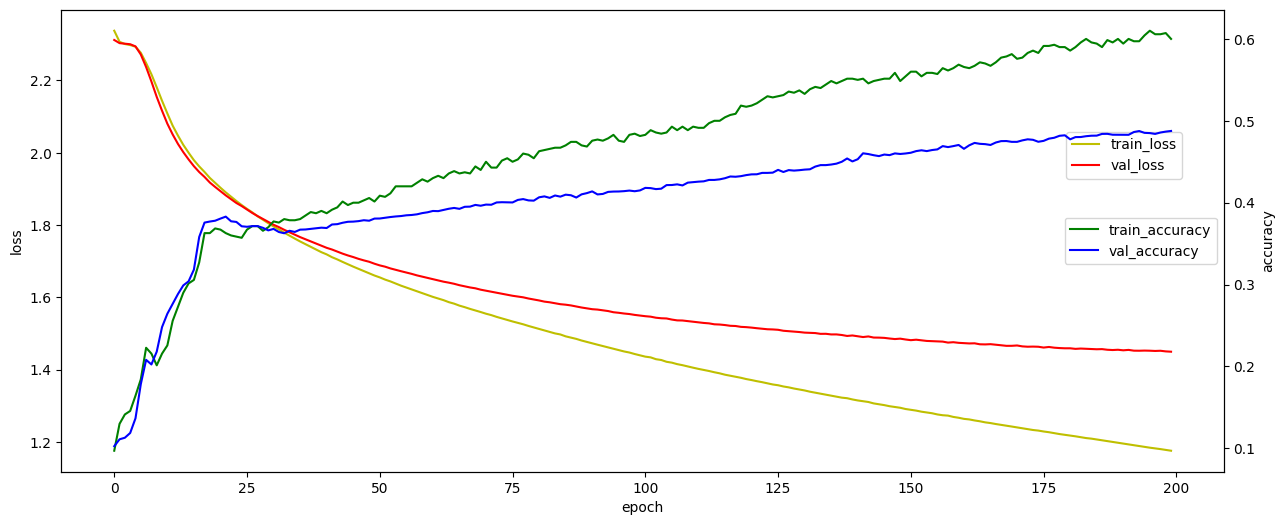

In [49]:
# 학습과정 살펴보기(시각화)
fig, loss_ax = plt.subplots(figsize=(15,6))
loss_ax.plot(hist.history['loss'], 'y', label='train_loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val_loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val_accuracy')

acc_ax.set_ylabel('accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(bbox_to_anchor=(0.97,0.75))
acc_ax.legend(loc='center right')
plt.show()

In [50]:
# 모델 평가(시험셋=test셋)
loss_metrics = model.evaluate(test_X, test_Y, batch_size=100, verbose=0)
print('loss :', loss_metrics[0])
print('accuracy :', loss_metrics[1])

loss : 1.4633527994155884
accuracy : 0.47699999809265137


# 👍위 모델(DNN)의 accuracy 늘리기
- 데이터 확보
- 모델 수정(레이어 추가, units수 증가)
- 과적합 방지(validation data추가, 활성화함수를 relu계열, tahn, Dropout추가, 배치정규화, L2정규화(규제)...)
- epoch 조정
- optimizer 변경

In [52]:
%%time
(X_train, y_train),(X_test, y_test) = mnist.load_data() #6만개, 만개로 분리되어 load
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]
# 입력(독립) 변수 (n,28,28) -> (n, 28*28) -> 실수로 형변환 ->스케일조정(/255.0)
train_X = X_train.reshape(50000, 28*28).astype('float32')/255.0
val_X   = X_val.reshape(10000, 784).astype('float32')/255.0
test_X  = X_test.reshape(10000, -1).astype('float32')/255.0
# 종속(타겟)변수 : 분류분석을 위한 원핫인코딩(to_categorical()이용, pd.getdummies)
train_Y = to_categorical(y_train, 10)
val_Y   = to_categorical(y_val)
test_Y  = to_categorical(y_test)
# Train 5만 -> 임의로 700개, val 1만 -> 임의로 300개 추출해서 학습(목적:수업시간 중 fit 시간 절약)
# train_idx = np.random.choice(50000, 700) # 0~50000미만의 700개 수 비복원추출
# val_idx   = np.random.choice(10000, 300)
# train_X = train_X[train_idx]
# train_Y = train_Y[train_idx]
# val_X   = val_X[val_idx]
# val_Y   = val_Y[val_idx]
print(train_X.shape, train_Y.shape, val_X.shape, val_Y.shape, test_X.shape, test_Y.shape)
# 모델생성(784->1024->512->128->10) 및 학습과정 설정
model = Sequential(name='sequential')
model.add(Input(shape=(784,)))
model.add(Dense(units=1024))
model.add(BatchNormalization()) # 1024개 출력층을 배치 정규화
model.add(LeakyReLU(alpha=0.01)) # 음수 결과에 대해 1%만 통과
model.add(Dropout(0.2))

model.add(Dense(units=512, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(units=128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.1))

model.add(Dense(units=10, activation='softmax'))
model.summary()
# 학습과정 설정 : 타겟변수를 원핫인코딩 안 했다면 sparse_categorical_crossentropy
model.compile(loss='categorical_crossentropy', 
             optimizer='adam',
             metrics=['accuracy']) # 평가지표
# 모델 학습
hist = model.fit(train_X, train_Y, #학습셋
                validation_data=(val_X, val_Y), # 검증셋
                batch_size=1000, # 크면 학습속도는 빨라지나 메모리 부족이 뜰 수도
                epochs=30, 
                verbose=2
                )

(50000, 784) (50000, 10) (10000, 784) (10000, 10) (10000, 784) (10000, 10)
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_6 (Dense)             (None, 1024)              803840    
                                                                 
 batch_normalization (BatchN  (None, 1024)             4096      
 ormalization)                                                   
                                                                 
 leaky_re_lu_3 (LeakyReLU)   (None, 1024)              0         
                                                                 
 dropout (Dropout)           (None, 1024)              0         
                                                                 
 dense_7 (Dense)             (None, 512)               524800    
                                                                 
 batch_normalization_1 (Batc  (None, 512)      

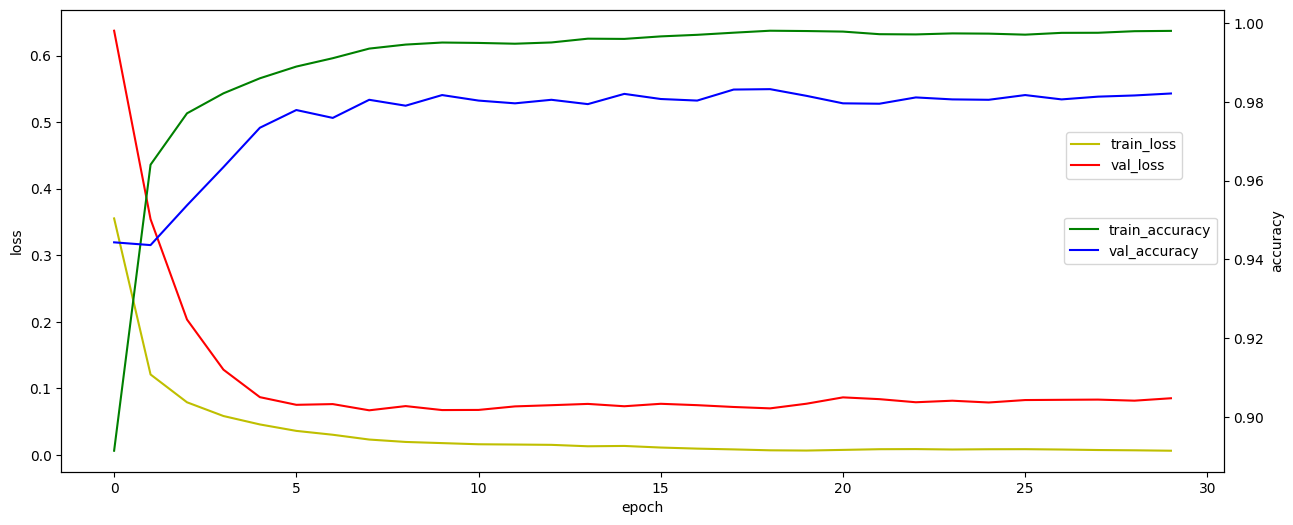

loss : 0.071524478495121
accuracy : 0.9818999767303467


In [53]:
# 학습과정 살펴보기(시각화)
fig, loss_ax = plt.subplots(figsize=(15,6))
loss_ax.plot(hist.history['loss'], 'y', label='train_loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val_loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val_accuracy')

acc_ax.set_ylabel('accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(bbox_to_anchor=(0.97,0.75))
acc_ax.legend(loc='center right')
plt.show()
# 모델 평가(시험셋=test셋)
loss_metrics = model.evaluate(test_X, test_Y, batch_size=100, verbose=0)
print('loss :', loss_metrics[0])
print('accuracy :', loss_metrics[1])

In [55]:
# 교차표
y_test # 실제값
test_Y.argmax(axis=1)
np.all(test_Y.argmax(axis=1) == y_test)

True

In [57]:
y_hat = model.predict(test_X)
y_hat = np.argmax(model.predict(test_X), axis=1)
y_hat

313/313 [==============================] - 1s 4ms/step


array([7, 2, 1, ..., 4, 5, 6], dtype=int64)

In [58]:
pd.crosstab(y_test, y_hat, rownames=['실제값'], colnames=['예측값'])

예측값,0,1,2,3,4,5,6,7,8,9
실제값,,,,,,,,,,
0,971,1,0,2,0,1,1,1,2,1
1,0,1124,3,1,0,1,3,1,2,0
2,0,0,1018,2,1,0,0,3,7,1
3,2,0,3,992,0,4,0,4,5,0
4,0,0,6,1,965,0,1,1,1,7
5,2,0,0,7,2,869,3,1,7,1
6,5,2,1,1,3,2,941,0,3,0
7,1,2,7,4,0,0,0,1004,5,5
8,0,0,2,4,1,0,0,2,963,2


In [59]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_hat)

array([[ 971,    1,    0,    2,    0,    1,    1,    1,    2,    1],
       [   0, 1124,    3,    1,    0,    1,    3,    1,    2,    0],
       [   0,    0, 1018,    2,    1,    0,    0,    3,    7,    1],
       [   2,    0,    3,  992,    0,    4,    0,    4,    5,    0],
       [   0,    0,    6,    1,  965,    0,    1,    1,    1,    7],
       [   2,    0,    0,    7,    2,  869,    3,    1,    7,    1],
       [   5,    2,    1,    1,    3,    2,  941,    0,    3,    0],
       [   1,    2,    7,    4,    0,    0,    0, 1004,    5,    5],
       [   0,    0,    2,    4,    1,    0,    0,    2,  963,    2],
       [   1,    2,    0,    3,    9,    3,    0,    7,   12,  972]],
      dtype=int64)

In [60]:
# 틀린 갯수
accuracy = loss_metrics[1]
10000*accuracy

9818.999767303467

# ※ 콜백함수 1 : 로그 출력

In [ ]:
%%time
(X_train, y_train),(X_test, y_test) = mnist.load_data() #6만개, 만개로 분리되어 load
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]
# 입력(독립) 변수 (n,28,28) -> (n, 28*28) -> 실수로 형변환 ->스케일조정(/255.0)
train_X = X_train.reshape(50000, 28*28).astype('float32')/255.0
val_X   = X_val.reshape(10000, 784).astype('float32')/255.0
test_X  = X_test.reshape(10000, -1).astype('float32')/255.0
# 종속(타겟)변수 : 분류분석을 위한 원핫인코딩(to_categorical()이용, pd.getdummies)
train_Y = to_categorical(y_train, 10)
val_Y   = to_categorical(y_val)
test_Y  = to_categorical(y_test)
# Train 5만 -> 임의로 700개, val 1만 -> 임의로 300개 추출해서 학습(목적:수업시간 중 fit 시간 절약)
train_idx = np.random.choice(50000, 700) # 0~50000미만의 700개 수 비복원추출
val_idx   = np.random.choice(10000, 300)
train_X = train_X[train_idx]
train_Y = train_Y[train_idx]
val_X   = val_X[val_idx]
val_Y   = val_Y[val_idx]
print(train_X.shape, train_Y.shape, val_X.shape, val_Y.shape, test_X.shape, test_Y.shape)
# 모델생성(784->2->10) 및 학습과정 설정
model = Sequential(name='sequential')
model.add(Input(shape=(784,)))
model.add(Dense(units=1024))
model.add(LeakyReLU(alpha=0.01)) # 음수 결과에 대해 1%만 통과

model.add(Dense(units=10, activation='softmax'))
model.summary()
# 학습과정 설정 : 타겟변수를 원핫인코딩 안 했다면 sparse_categorical_crossentropy
model.compile(loss='categorical_crossentropy', 
             optimizer='adam',
             metrics=['accuracy']) # 평가지표
# 모델 학습
hist = model.fit(train_X, train_Y, #학습셋
                validation_data=(val_X, val_Y), # 검증셋
                batch_size=1000, # 크면 학습속도는 빨라지나 메모리 부족이 뜰 수도
                epochs=200, 
                verbose=2
                )